In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
import sys

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
df = pd.read_csv("diabetes.csv")
print("Dataset imported successfully.")

print("\nDataset shape:")
print(df.shape)

print("\nFirst 10 rows of the dataset:")
df.head(10)

Dataset imported successfully.

Dataset shape:
(768, 9)

First 10 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [6]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nData types of each column:")
display(df.dtypes)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Data types of each column:


Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [ ]:
# Cell 8: Count outliers compared to total rows

total_rows = len(df)
outlier_count = len(outliers)
outlier_percentage = (outlier_count / total_rows) * 100

print("Total number of rows:", total_rows)
print("Number of outliers found:", outlier_count)
print("Percentage of outliers:", round(outlier_percentage, 2), "%")

In [7]:
print("\nMissing values in each column:")
display(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

print("\nStatistical summary of numerical columns:")
display(df.describe())


Missing values in each column:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Number of duplicate rows:
0

Statistical summary of numerical columns:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


EDA Summary
----------------------------------------
Outcome Summary:


,Outcome,Count,Percentage
0,0,500,65.1
1,1,268,34.9


Zero Values in Important Health Columns:


,Column,Zero Values
0,Glucose,5
1,BloodPressure,35
2,SkinThickness,227
3,Insulin,374
4,BMI,11


BloodPressure Summary:


,count,mean,std,min,25%,50%,75%,max
BloodPressure,768.0,69.105469,19.355807,0.0,62.0,72.0,80.0,122.0


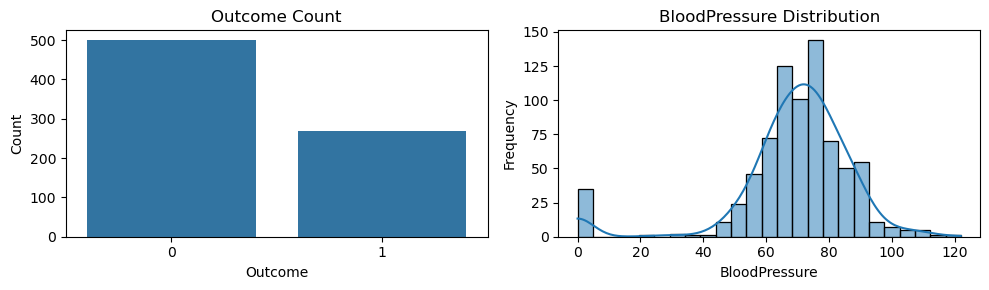

In [8]:
# Cell 4: Exploratory Data Analysis (EDA)

print("EDA Summary")
print("-" * 40)

# Outcome summary
outcome_summary = pd.DataFrame({
    "Outcome": df["Outcome"].value_counts().index,
    "Count": df["Outcome"].value_counts().values,
    "Percentage": (df["Outcome"].value_counts(normalize=True).values * 100).round(2)
})

# Zero value summary
health_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_summary = pd.DataFrame({
    "Column": health_columns,
    "Zero Values": [(df[col] == 0).sum() for col in health_columns]
})

# BloodPressure summary
bp_summary = df["BloodPressure"].describe().to_frame().T

print("Outcome Summary:")
display(outcome_summary)

print("Zero Values in Important Health Columns:")
display(zero_summary)

print("BloodPressure Summary:")
display(bp_summary)

# EDA visualization
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x="Outcome")
plt.title("Outcome Count")
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.histplot(data=df, x="BloodPressure", bins=25, kde=True)
plt.title("BloodPressure Distribution")
plt.xlabel("BloodPressure")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

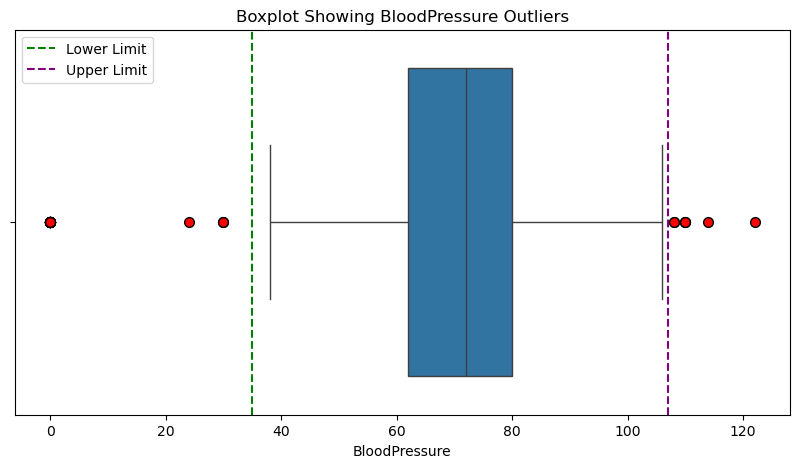

In [21]:
# Cell 5: Visual Detection - Boxplot with outliers marked in red
column = "BloodPressure"
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x=column,
    flierprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": 7
    }
)

plt.axvline(lower_limit, color="green", linestyle="--", label="Lower Limit")
plt.axvline(upper_limit, color="purple", linestyle="--", label="Upper Limit")

plt.title("Boxplot Showing BloodPressure Outliers")
plt.xlabel("BloodPressure")
plt.legend()
plt.show()


In [24]:
# Statistical Identification using both IQR and Z-score

column = "BloodPressure"

print("Statistical Identification of Outliers")
print("-" * 50)
# IQR METHOD
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df["IQR_Outlier"] = "Normal"
df.loc[(df[column] < lower_limit) | (df[column] > upper_limit), "IQR_Outlier"] = "Outlier"

print("IQR Method Results")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)


# Z-SCORE METHOD
mean_value = df[column].mean()
std_value = df[column].std()

df["Z_Score"] = (df[column] - mean_value) / std_value

df["Z_Outlier"] = "Normal"
df.loc[df["Z_Score"].abs() > 3, "Z_Outlier"] = "Outlier"

print("\nZ-score Method Results")
print("Mean/Average:", mean_value)
print("Standard Deviation:", std_value)
print("Z-score Threshold: Greater than 3 or less than -3")


# FINAL OUTLIER STATUS
df["Final_Outlier_Status"] = "Normal"

df.loc[
    (df["IQR_Outlier"] == "Outlier") | (df["Z_Outlier"] == "Outlier"),
    "Final_Outlier_Status"
] = "Outlier"

print("\nOutlier columns added successfully.")

display(df[[column, "IQR_Outlier", "Z_Score", "Z_Outlier", "Final_Outlier_Status"]].head(15))

Statistical Identification of Outliers
--------------------------------------------------
IQR Method Results
Q1: 62.0
Q3: 80.0
IQR: 18.0
Lower Limit: 35.0
Upper Limit: 107.0

Z-score Method Results
Mean/Average: 69.10546875
Standard Deviation: 19.355807170644777
Z-score Threshold: Greater than 3 or less than -3

Outlier columns added successfully.


,BloodPressure,IQR_Outlier,Z_Score,Z_Outlier,Final_Outlier_Status
0,72,Normal,0.149543,Normal,Normal
1,66,Normal,-0.160441,Normal,Normal
2,64,Normal,-0.263769,Normal,Normal
3,66,Normal,-0.160441,Normal,Normal
4,40,Normal,-1.503707,Normal,Normal
5,74,Normal,0.252871,Normal,Normal
6,50,Normal,-0.987066,Normal,Normal
7,0,Outlier,-3.570271,Outlier,Outlier
8,70,Normal,0.046215,Normal,Normal
9,96,Normal,1.389481,Normal,Normal


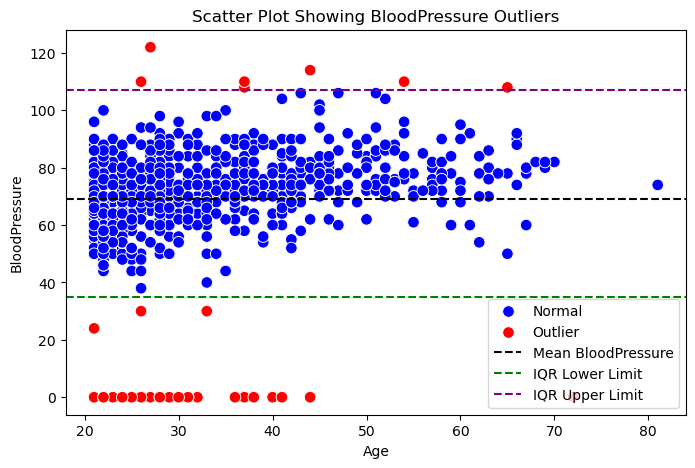

In [26]:
# Scatter plot showing BloodPressure outliers

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="BloodPressure",
    hue="Final_Outlier_Status",
    palette={"Normal": "blue", "Outlier": "red"},
    s=70
)

plt.axhline(mean_value, color="black", linestyle="--", label="Mean BloodPressure")
plt.axhline(lower_limit, color="green", linestyle="--", label="IQR Lower Limit")
plt.axhline(upper_limit, color="purple", linestyle="--", label="IQR Upper Limit")

plt.title("Scatter Plot Showing BloodPressure Outliers")
plt.xlabel("Age")
plt.ylabel("BloodPressure")
plt.legend()
plt.show()

In [29]:
# Cell 8: The Odd List - Short version for one screenshot

outliers = df[df["Final_Outlier_Status"] == "Outlier"].copy()
outliers["Z_Score"] = outliers["Z_Score"].round(2)

odd_list = outliers[
    ["BloodPressure", "Age", "Outcome", "IQR_Outlier", "Z_Score", "Z_Outlier", "Final_Outlier_Status"]
].sort_values(by="BloodPressure").reset_index()

odd_list = odd_list.rename(columns={"index": "Row Number"})

# Show 5 lowest and 5 highest outliers
lowest_outliers = odd_list.head(5)
highest_outliers = odd_list.tail(5)

odd_list_short = pd.concat([lowest_outliers, highest_outliers])

print("The Odd List: Sample of Rows Flagged as Outliers")
print("-" * 55)
print("Total outlier rows found:", len(outliers))
print("Showing 5 lowest and 5 highest BloodPressure outliers")

display(odd_list_short)

The Odd List: Sample of Rows Flagged as Outliers
-------------------------------------------------------
Total outlier rows found: 45
Showing 5 lowest and 5 highest BloodPressure outliers


,Row Number,BloodPressure,Age,Outcome,IQR_Outlier,Z_Score,Z_Outlier,Final_Outlier_Status
0,7,0,29,0,Outlier,-3.57,Outlier,Outlier
1,15,0,32,1,Outlier,-3.57,Outlier,Outlier
2,60,0,21,0,Outlier,-3.57,Outlier,Outlier
3,49,0,24,0,Outlier,-3.57,Outlier,Outlier
4,78,0,26,1,Outlier,-3.57,Outlier,Outlier
40,43,110,54,1,Outlier,2.11,Normal,Outlier
41,177,110,26,1,Outlier,2.11,Normal,Outlier
42,549,110,37,0,Outlier,2.11,Normal,Outlier
43,691,114,44,1,Outlier,2.32,Normal,Outlier
44,106,122,27,0,Outlier,2.73,Normal,Outlier


In [ ]:
# Count outliers compared to total rows

total_rows = len(df)
outlier_count = len(outliers)
normal_count = total_rows - outlier_count
outlier_percentage = (outlier_count / total_rows) * 100

print("Outlier Count Summary")
print("-" * 40)
print("Total number of rows:", total_rows)
print("Number of normal rows:", normal_count)
print("Number of outlier rows:", outlier_count)
print("Percentage of outliers:", round(outlier_percentage, 2), "%")

Outlier Count Summary
----------------------------------------
Total number of rows: 768
Number of normal rows: 723
Number of outlier rows: 45
Percentage of outliers: 5.86 %


In [ ]:
# Check whether outliers are much lower or much higher

low_outliers = outliers[outliers["BloodPressure"] < mean_value]
high_outliers = outliers[outliers["BloodPressure"] > mean_value]

print("Low and High Outlier Summary")
print("-" * 40)
print("Mean/Average BloodPressure:", round(mean_value, 2))
print("Number of low outliers:", len(low_outliers))
print("Number of high outliers:", len(high_outliers))

summary_table = pd.DataFrame({
    "Outlier Type": ["Low BloodPressure Outliers", "High BloodPressure Outliers"],
    "Count": [len(low_outliers), len(high_outliers)]
})

display(summary_table)

Low and High Outlier Summary
----------------------------------------
Mean/Average BloodPressure: 69.11
Number of low outliers: 38
Number of high outliers: 7


,Outlier Type,Count
0,Low BloodPressure Outliers,38
1,High BloodPressure Outliers,7
